In [45]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt

In [46]:
model         = joblib.load("saved_models/best_lgbm.pkl")
transformer   = joblib.load("saved_models/transformer.pkl")
X_test_final  = joblib.load("saved_models/X_test_final.pkl")
y_test        = joblib.load("saved_models/y_test.pkl")

with open("saved_models/metadata.json", "r") as f:
    metadata = json.load(f)

FEATURE_NAMES = metadata["feature_names"]
THRESHOLD     = metadata["final_threshold"]

print("✓ Semua artifacts berhasil di-load")
print(f"  FEATURE_NAMES  : {FEATURE_NAMES}")
print(f"  THRESHOLD      : {THRESHOLD}")
print(f"  X_test_final   : {X_test_final.shape}")
print(f"  y_test         : {y_test.shape}")

✓ Semua artifacts berhasil di-load
  FEATURE_NAMES  : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'WeightedLateScore', 'LogIncome', 'DisposableIncome', 'LogDebtRatio']
  THRESHOLD      : 0.3
  X_test_final   : (29876, 9)
  y_test         : (29876,)


In [47]:
df_test_raw = pd.read_csv("cs-test.csv")

df_test_raw.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")

if "SeriousDlqin2yrs" in df_test_raw.columns:
    df_test_raw.drop(columns=["SeriousDlqin2yrs"], inplace=True)

print(f"✓ Test data shape: {df_test_raw.shape}")
print(df_test_raw.head())

✓ Test data shape: (101503, 10)
   RevolvingUtilizationOfUnsecuredLines  age  \
0                              0.885519   43   
1                              0.463295   57   
2                              0.043275   59   
3                              0.280308   38   
4                              1.000000   27   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     0   0.177513         5700.0   
1                                     0   0.527237         9141.0   
2                                     0   0.687648         5083.0   
3                                     1   0.925961         3200.0   
4                                     0   0.019917         3865.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                                4                        0   
1                               15                        0   
2                               12                        0   
3           

In [48]:
df_inf = df_test_raw.copy()

df_inf["IncomeMissingFlag"]     = df_inf["MonthlyIncome"].isnull().astype(int)
df_inf["DependentsMissingFlag"] = df_inf["NumberOfDependents"].isnull().astype(int)

INCOME_MEDIAN     = 5400.0
DEPENDENTS_MEDIAN = 0.0

df_inf["MonthlyIncome"].fillna(INCOME_MEDIAN, inplace=True)
df_inf["NumberOfDependents"].fillna(DEPENDENTS_MEDIAN, inplace=True)

print("Missing setelah impute:")
print(df_inf[["MonthlyIncome", "NumberOfDependents"]].isnull().sum())

Missing setelah impute:
MonthlyIncome         0
NumberOfDependents    0
dtype: int64


C:\Users\rezha\AppData\Local\Temp\ipykernel_16572\1676036602.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_inf["MonthlyIncome"].fillna(INCOME_MEDIAN, inplace=True)
C:\Users\rezha\AppData\Local\Temp\ipykernel_16572\1676036602.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [49]:
CLIP_BOUNDS = {
    "RevolvingUtilizationOfUnsecuredLines": (0.0, 1.09393041),
    "DebtRatio":                            (0.0, 4985.24),
    "MonthlyIncome":                        (0.0, 23085.4),
}

for col, (lo, hi) in CLIP_BOUNDS.items():
    df_inf[col] = df_inf[col].clip(lo, hi)

print("✓ Clipping selesai")
print(df_inf[list(CLIP_BOUNDS.keys())].describe().loc[["min", "max"]])

✓ Clipping selesai
     RevolvingUtilizationOfUnsecuredLines  DebtRatio  MonthlyIncome
min                               0.00000       0.00            0.0
max                               1.09393    4985.24        23085.4


In [50]:
df_inf["RevolvingUtilizationOfUnsecuredLines"] = np.log1p(
    df_inf["RevolvingUtilizationOfUnsecuredLines"]
)

count_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
]
for col in count_cols:
    df_inf[col] = df_inf[col].clip(0, 10)

print("✓ Log transform & count clipping selesai")

✓ Log transform & count clipping selesai


In [51]:
before = len(df_inf)
df_inf = df_inf[(df_inf["age"] >= 18) & (df_inf["age"] <= 100)].reset_index(drop=True)
after  = len(df_inf)

print(f"✓ Filter usia: {before - after} baris dihapus")
print(f"  Shape sekarang: {df_inf.shape}")

✓ Filter usia: 3 baris dihapus
  Shape sekarang: (101500, 12)


In [52]:
df_inf["WeightedLateScore"] = (
    df_inf["NumberOfTime30-59DaysPastDueNotWorse"] * 1 +
    df_inf["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
    df_inf["NumberOfTimes90DaysLate"]               * 4
)

df_inf["LogIncome"]        = np.log1p(df_inf["MonthlyIncome"])
df_inf["MonthlyDebt"]      = np.log1p(df_inf["MonthlyIncome"] * df_inf["DebtRatio"])
df_inf["DisposableIncome"] = df_inf["MonthlyIncome"] * (1 - df_inf["DebtRatio"])
df_inf["LogDebtRatio"]     = np.log1p(df_inf["DebtRatio"])

print("✓ Feature engineering selesai")
print(f"  Kolom: {df_inf.columns.tolist()}")

✓ Feature engineering selesai
  Kolom: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'IncomeMissingFlag', 'DependentsMissingFlag', 'WeightedLateScore', 'LogIncome', 'MonthlyDebt', 'DisposableIncome', 'LogDebtRatio']


In [53]:
cols_to_drop = [
    "NumberOfTimes90DaysLate",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "MonthlyIncome",
    "DebtRatio",
    "MonthlyDebt",
    "DependentsMissingFlag",
    "IncomeMissingFlag",
]
df_inf.drop(columns=cols_to_drop, inplace=True, errors="ignore")

X_inf = df_inf[FEATURE_NAMES]

print("✓ Drop & align selesai")
print(f"  Shape X_inf: {X_inf.shape}")
print(f"  Kolom: {X_inf.columns.tolist()}")

✓ Drop & align selesai
  Shape X_inf: (101500, 9)
  Kolom: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'WeightedLateScore', 'LogIncome', 'DisposableIncome', 'LogDebtRatio']


In [54]:
X_inf_scaled = transformer.transform(X_inf)

print("✓ Scaling selesai")
print(f"  Shape: {X_inf_scaled.shape}")

✓ Scaling selesai
  Shape: (101500, 9)


In [55]:
prob_default    = model.predict_proba(X_inf_scaled)[:, 1]
prob_no_default = 1 - prob_default

print("✓ Prediksi selesai")
print(f"  Total nasabah        : {len(prob_default):,}")
print(f"  Rata-rata P(default) : {prob_default.mean():.4f}")
print(f"  Min                  : {prob_default.min():.4f}")
print(f"  Max                  : {prob_default.max():.4f}")
print()
print(pd.Series(prob_default).describe().round(4))

c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✓ Prediksi selesai
  Total nasabah        : 101,500
  Rata-rata P(default) : 0.3190
  Min                  : 0.0217
  Max                  : 0.9880

count    101500.0000
mean          0.3190
std           0.2557
min           0.0217
25%           0.1122
50%           0.2219
75%           0.4830
max           0.9880
dtype: float64


In [56]:
# Gunakan X_test_final & y_test dari training (data berlabel asli)
y_prob_eval = model.predict_proba(X_test_final)[:, 1]

df_ks = pd.DataFrame({
    "y_true":  y_test.values,
    "y_score": y_prob_eval
})
df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)

total_bad  = df_ks["y_true"].sum()
total_good = len(df_ks) - total_bad

df_ks["cum_bad_rate"]  = df_ks["y_true"].cumsum() / total_bad
df_ks["cum_good_rate"] = (1 - df_ks["y_true"]).cumsum() / total_good
df_ks["KS"]            = (df_ks["cum_bad_rate"] - df_ks["cum_good_rate"]).abs()

ks_stat      = df_ks["KS"].max()
ks_threshold = df_ks.loc[df_ks["KS"].idxmax(), "y_score"]

print(f"✓ KS Statistic : {ks_stat:.4f}")
print(f"  KS Threshold : {ks_threshold:.4f}  ← titik pemisah optimal")
print()
if ks_stat >= 0.5:
    print("  Interpretasi : Good model (KS ≥ 0.5)")
elif ks_stat >= 0.2:
    print("  Interpretasi : Acceptable model (0.2 ≤ KS < 0.5)")
else:
    print("  Interpretasi : Weak model (KS < 0.2)")

c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✓ KS Statistic : 0.5836
  KS Threshold : 0.4866  ← titik pemisah optimal

  Interpretasi : Good model (KS ≥ 0.5)


In [57]:
margin = ks_threshold * 0.10   # buffer ±10% di sekitar KS threshold

high_bound   = ks_threshold + margin
medium_bound = ks_threshold - margin

print("══════════════════════════════════════════")
print("  RISK THRESHOLDS (dari KS Statistic)")
print("══════════════════════════════════════════")
print(f"  KS Threshold : {ks_threshold:.4f}")
print(f"  Margin (10%) : {margin:.4f}")
print()
print(f"  High Risk    : P(default) >= {high_bound:.4f}")
print(f"  Medium Risk  : {medium_bound:.4f} <= P(default) < {high_bound:.4f}")
print(f"  Low Risk     : P(default) <  {medium_bound:.4f}")

══════════════════════════════════════════
  RISK THRESHOLDS (dari KS Statistic)
══════════════════════════════════════════
  KS Threshold : 0.4866
  Margin (10%) : 0.0487

  High Risk    : P(default) >= 0.5353
  Medium Risk  : 0.4380 <= P(default) < 0.5353
  Low Risk     : P(default) <  0.4380


In [58]:
def assign_risk(p):
    if p >= high_bound:
        return "High Risk"
    elif p >= medium_bound:
        return "Medium Risk"
    else:
        return "Low Risk"

df_output = df_test_raw.loc[df_inf.index].reset_index(drop=True).copy()
df_output["prob_no_default"] = (prob_no_default * 100).round(2)
df_output["prob_default"]    = (prob_default    * 100).round(2)
df_output["risk_category"]   = [assign_risk(p) for p in prob_default]

print("══════════════════════════════════════════")
print("  DISTRIBUSI RISK CATEGORY")
print("══════════════════════════════════════════")
risk_counts = df_output["risk_category"].value_counts().reindex(
    ["High Risk", "Medium Risk", "Low Risk"]
)
risk_pct = risk_counts / risk_counts.sum() * 100
print(pd.DataFrame({
    "Jumlah Nasabah": risk_counts,
    "Persentase (%)": risk_pct.round(2)
}))

print("\nSample hasil:")
print(df_output[["age", "prob_no_default", "prob_default", "risk_category"]].head(10))

══════════════════════════════════════════
  DISTRIBUSI RISK CATEGORY
══════════════════════════════════════════
               Jumlah Nasabah  Persentase (%)
risk_category                                
High Risk               21393           21.08
Medium Risk              7494            7.38
Low Risk                72613           71.54

Sample hasil:
   age  prob_no_default  prob_default risk_category
0   43            51.30         48.70   Medium Risk
1   57            62.56         37.44      Low Risk
2   59            80.90         19.10      Low Risk
3   38            46.46         53.54     High Risk
4   27            40.47         59.53     High Risk
5   63            67.75         32.25      Low Risk
6   50            66.17         33.83      Low Risk
7   79            74.83         25.17      Low Risk
8   68            97.18          2.82      Low Risk
9   23            10.02         89.98     High Risk


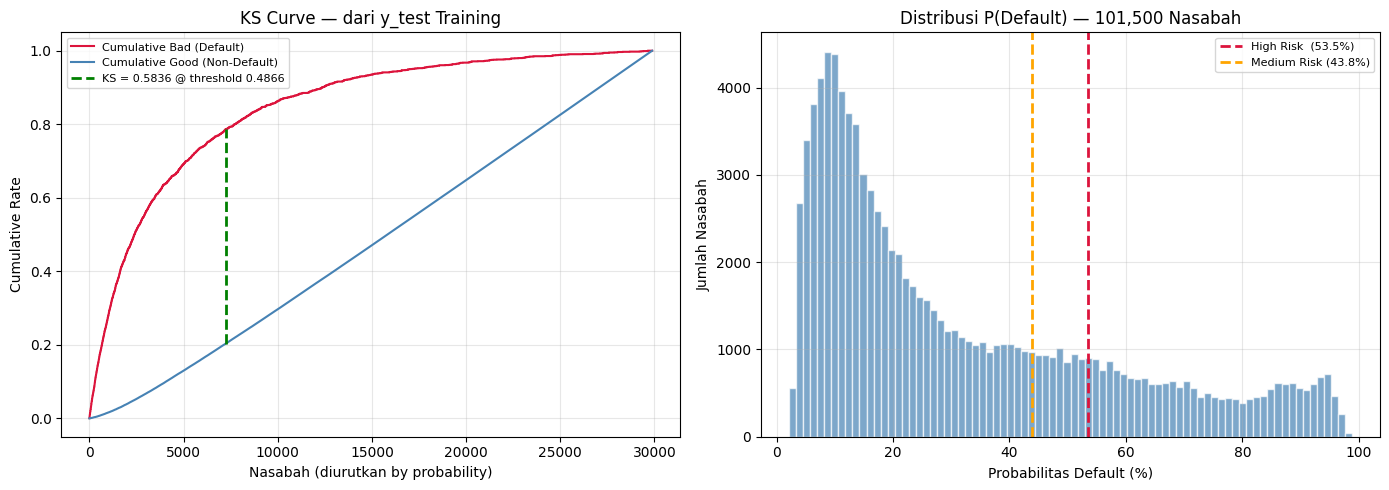

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KS Curve
axes[0].plot(df_ks.index, df_ks["cum_bad_rate"],
             label="Cumulative Bad (Default)", color="crimson")
axes[0].plot(df_ks.index, df_ks["cum_good_rate"],
             label="Cumulative Good (Non-Default)", color="steelblue")

ks_idx = df_ks["KS"].idxmax()
axes[0].vlines(
    x=ks_idx,
    ymin=df_ks.loc[ks_idx, "cum_good_rate"],
    ymax=df_ks.loc[ks_idx, "cum_bad_rate"],
    colors="green", linestyles="--", linewidth=2,
    label=f"KS = {ks_stat:.4f} @ threshold {ks_threshold:.4f}"
)
axes[0].set_title("KS Curve — dari y_test Training")
axes[0].set_xlabel("Nasabah (diurutkan by probability)")
axes[0].set_ylabel("Cumulative Rate")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Distribusi probabilitas + batas threshold
axes[1].hist(prob_default * 100, bins=80,
             color="steelblue", alpha=0.7, edgecolor="white")
axes[1].axvline(high_bound   * 100, color="crimson", linestyle="--",
                linewidth=2, label=f"High Risk  ({high_bound*100:.1f}%)")
axes[1].axvline(medium_bound * 100, color="orange",  linestyle="--",
                linewidth=2, label=f"Medium Risk ({medium_bound*100:.1f}%)")
axes[1].set_title(f"Distribusi P(Default) — {len(prob_default):,} Nasabah")
axes[1].set_xlabel("Probabilitas Default (%)")
axes[1].set_ylabel("Jumlah Nasabah")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

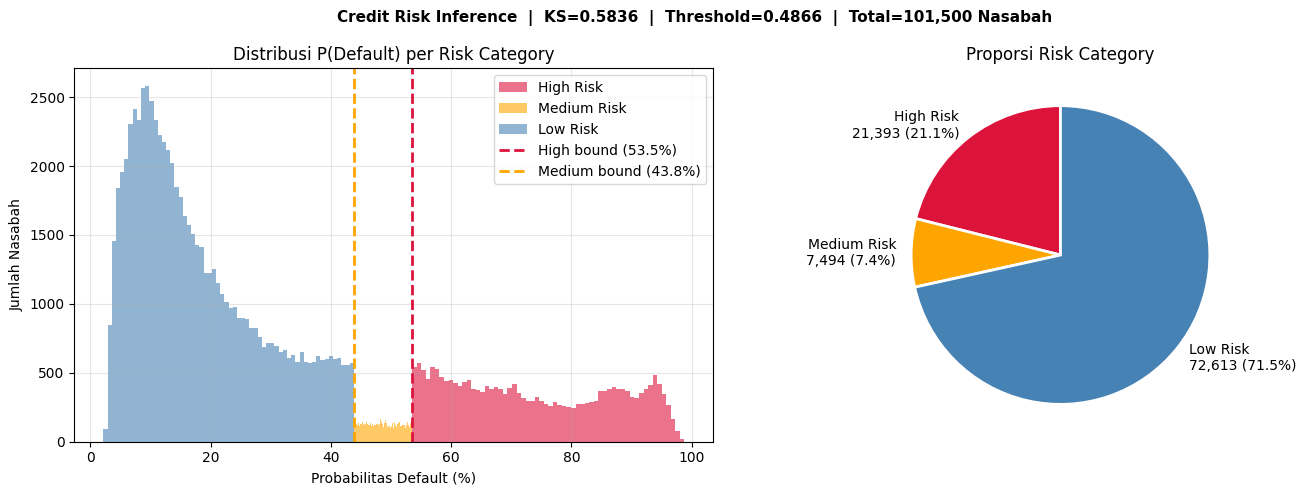

In [60]:
color_map = {"High Risk": "crimson", "Medium Risk": "orange", "Low Risk": "steelblue"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram per kategori
for cat, color in color_map.items():
    subset = df_output.loc[df_output["risk_category"] == cat, "prob_default"]
    axes[0].hist(subset, bins=60, alpha=0.6, label=cat, color=color)

axes[0].axvline(high_bound   * 100, color="crimson", linestyle="--",
                linewidth=2, label=f"High bound ({high_bound*100:.1f}%)")
axes[0].axvline(medium_bound * 100, color="orange",  linestyle="--",
                linewidth=2, label=f"Medium bound ({medium_bound*100:.1f}%)")
axes[0].set_title("Distribusi P(Default) per Risk Category")
axes[0].set_xlabel("Probabilitas Default (%)")
axes[0].set_ylabel("Jumlah Nasabah")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Pie chart
cat_order  = ["High Risk", "Medium Risk", "Low Risk"]
cat_colors = ["crimson", "orange", "steelblue"]
cat_counts = [risk_counts[c] for c in cat_order]
cat_labels = [f"{c}\n{n:,} ({n/sum(cat_counts)*100:.1f}%)"
              for c, n in zip(cat_order, cat_counts)]

axes[1].pie(cat_counts, labels=cat_labels, colors=cat_colors,
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proporsi Risk Category")

plt.suptitle(
    f"Credit Risk Inference  |  KS={ks_stat:.4f}  |  Threshold={ks_threshold:.4f}  |  "
    f"Total={len(prob_default):,} Nasabah",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [61]:
df_output.to_csv("inference_results.csv", index=False)

print("✓ Hasil disimpan ke: inference_results.csv")
print(f"  Total baris : {len(df_output):,}")
print(f"  Kolom       : {df_output.columns.tolist()}")

✓ Hasil disimpan ke: inference_results.csv
  Total baris : 101,500
  Kolom       : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'prob_no_default', 'prob_default', 'risk_category']


In [62]:
from IPython.display import display

# ── Styling functions ──────────────────────────────────────
def color_risk(val):
    colors = {
        "High Risk":   "background-color: #f8d7da; color: #842029; font-weight: bold;",
        "Medium Risk": "background-color: #fff3cd; color: #664d03; font-weight: bold;",
        "Low Risk":    "background-color: #d1e7dd; color: #0f5132; font-weight: bold;",
    }
    return colors.get(val, "")

def color_prob(val):
    if val >= high_bound * 100:
        return "color: #842029; font-weight: bold;"
    elif val >= medium_bound * 100:
        return "color: #664d03; font-weight: bold;"
    else:
        return "color: #0f5132; font-weight: bold;"

# ── Ambil semua kolom dari raw test + hasil prediksi ───────
df_display = df_test_raw.loc[df_inf.index].reset_index(drop=True).copy()

df_display["P(Not Default) %"] = (prob_no_default * 100).round(2)
df_display["P(Default) %"]     = (prob_default    * 100).round(2)
df_display["Risk Category"]    = [assign_risk(p) for p in prob_default]

# ── Tampilkan 50 baris pertama saja ───────────────────────
styled = (
    df_display.head(20)
    .style
    .applymap(color_risk, subset=["Risk Category"])
    .applymap(color_prob, subset=["P(Default) %"])
    .format({
        "RevolvingUtilizationOfUnsecuredLines": "{:.4f}",
        "DebtRatio":                            "{:.4f}",
        "MonthlyIncome":                        "{:,.0f}",
        "P(Not Default) %":                     "{:.2f}%",
        "P(Default) %":                         "{:.2f}%",
    })
    .set_caption("📋 Hasil Inference Credit Risk — 50 Data Pertama")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("margin-bottom", "8px")]},
        {"selector": "thead th",
         "props": [("background-color", "#343a40"), ("color", "white"),
                   ("text-align", "center"), ("padding", "8px"),
                   ("white-space", "nowrap")]},
        {"selector": "tbody td",
         "props": [("text-align", "center"), ("padding", "6px")]},
        {"selector": "tbody tr:hover",
         "props": [("background-color", "#f0f0f0")]},
    ])
)

display(styled)

C:\Users\rezha\AppData\Local\Temp\ipykernel_16572\527941036.py:29: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_display.head(20)


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,P(Not Default) %,P(Default) %,Risk Category
0,0.8855,43,0,0.1775,"5,700",4,0,0,0,0.000000,51.30%,48.70%,Medium Risk
1,0.4633,57,0,0.5272,"9,141",15,0,4,0,2.000000,62.56%,37.44%,Low Risk
2,0.0433,59,0,0.6876,"5,083",12,0,1,0,2.000000,80.90%,19.10%,Low Risk
3,0.2803,38,1,0.9260,"3,200",7,0,2,0,0.000000,46.46%,53.54%,High Risk
4,1.0000,27,0,0.0199,"3,865",4,0,0,0,1.000000,40.47%,59.53%,High Risk
5,0.5098,63,0,0.3424,"4,140",4,0,0,0,1.000000,67.75%,32.25%,Low Risk
6,0.5878,50,0,1048.0000,0,5,0,0,0,3.000000,66.17%,33.83%,Low Risk
7,0.0461,79,1,0.3692,"3,301",8,0,1,0,1.000000,74.83%,25.17%,Low Risk
8,0.0135,68,0,2024.0000,nan,4,0,1,0,0.000000,97.18%,2.82%,Low Risk
9,1.0000,23,98,0.0000,0,0,98,0,98,0.000000,10.02%,89.98%,High Risk


In [63]:
import joblib
import json
import numpy as np
import pandas as pd

best_lgbm   = joblib.load("saved_models/best_lgbm.pkl")
transformer = joblib.load("saved_models/transformer.pkl")

with open("saved_models/metadata.json", "r") as f:
    metadata = json.load(f)

print("✓ Artifacts loaded")

✓ Artifacts loaded


In [ ]:
# Simulasi manual dengan nilai yang sama persis dengan Streamlit
import numpy as np

util      = 0.4633
debt      = 0.53
inc       = 5000.0
age       = 57
open_loans = 15
real_estate = 4
dependents  = 2.0
late_30_59  = 0
late_60_89  = 0
late_90     = 0

# Preprocessing (sama dengan training)
util_clipped = np.clip(util, 0.0, 1.09393041)
debt_clipped = np.clip(debt, 0.0, 4985.24)
inc_clipped  = np.clip(inc,  0.0, 23085.4)

open_loans_clipped  = np.clip(open_loans,  0, 10)
real_estate_clipped = np.clip(real_estate, 0, 10)
dependents_clipped  = np.clip(dependents,  0, 10)

util_log          = np.log1p(util_clipped)
log_income        = np.log1p(inc_clipped)
disposable_income = inc_clipped * (1 - debt_clipped)
log_debt_ratio    = np.log1p(debt_clipped)
weighted_late     = late_30_59 * 1 + late_60_89 * 2 + late_90 * 4

import pandas as pd

X_manual = pd.DataFrame([{
    "RevolvingUtilizationOfUnsecuredLines": util_log,
    "age":                                  age,
    "NumberOfOpenCreditLinesAndLoans":      open_loans_clipped,
    "NumberRealEstateLoansOrLines":         real_estate_clipped,
    "NumberOfDependents":                   dependents_clipped,
    "WeightedLateScore":                    weighted_late,
    "LogIncome":                            log_income,
    "DisposableIncome":                     disposable_income,
    "LogDebtRatio":                         log_debt_ratio,
}])

X_manual_scaled = transformer.transform(X_manual)
prob = best_lgbm.predict_proba(X_manual_scaled)[0][1]

print(f"Probabilitas manual : {prob*100:.2f}%")
print(f"Streamlit hasil     : 40.84%")
print(f"Selisih             : {abs(prob*100 - 40.84):.2f}%")
print()
print("Detail fitur yang masuk model:")
print(X_manual.T)

Probabilitas manual : 40.84%
Streamlit hasil     : 40.84%
Selisih             : 0.00%

Detail fitur yang masuk model:
                                                0
RevolvingUtilizationOfUnsecuredLines     0.380694
age                                     57.000000
NumberOfOpenCreditLinesAndLoans         10.000000
NumberRealEstateLoansOrLines             4.000000
NumberOfDependents                       2.000000
WeightedLateScore                        0.000000
LogIncome                                8.517393
DisposableIncome                      2350.000000
LogDebtRatio                             0.425268


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
